# Building a sample dataset for testing derivative products across different Landsat sensors

This notebook is designed to create a sample set for testing derivative products across the continent, where the testing needs to compare data derived from multiple landsat sensors. It is designed to do the following:

- Import a geojson containing the footprints of the 'golden tiles' that have been previously used for validating GeoMAD products. These tiles are distributed across Australia and across a range of environment types.
- Load a datacube dataset for the selected sensors (in this case, Landsat 7, and Landsat 8/9), using one or more of the golden tiles as the geometry for the datacube query
- Compare the resulting datasets and find the timesteps that overlap ( +/- a timeframe set by the user, e.g. 48 hours)
- If the resulting filtered dataset is very large, create a subset based on randomly selecting smaller regions or pixels
- Export the resulting geojson so it can be used as an input to test workflows

In [1]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import pprint
from datetime import timedelta
import matplotlib.pyplot as plt
from datacube.utils.geometry import CRS, Geometry, GeoBox
from datacube.utils import masking


import sys
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.dask import create_local_dask_cluster
from dea_tools.plotting import rgb, display_map

In [2]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 7,Total memory: 59.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43529,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 7
Started: Just now,Total memory: 59.21 GiB
Comm: tcp://127.0.0.1:35737,Total threads: 7
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/37669/status,Memory: 59.21 GiB
Nanny: tcp://127.0.0.1:35519,


In [3]:
dc = datacube.Datacube()

In [4]:
def display_polygon(gdf, code):
    code=[code]
    gdf = gdf[gdf['region_code'].isin(code)]
    polygon = gdf.geometry.iloc[0]
    geom = Geometry(geom=polygon, crs=gdf.crs)
    
    bounds = geom.boundingbox
    x_range = (bounds.left, bounds.right)
    y_range = (bounds.bottom, bounds.top)
    
    return x_range, y_range

In [5]:
def select_tile(grid_gdf, region_code, query):
    region_code=[region_code]
    gdf = grid_gdf[grid_gdf['region_code'].isin(region_code)]
    polygon = gdf.geometry.iloc[0]
    
    geom = Geometry(geom=polygon, crs=gdf.crs)
    query.update({'geopolygon': geom})
    
    return query

In [6]:
def filter_dataset_within_timeframe(ds1, ds2, buffer_days):
    buffer = pd.Timedelta(days=buffer_days)


    # filter by time: keep ds2 times within buffer of any ds1 time
    valid_times = [
        t for t in ds2.time.values
        if ((t - buffer <= ds1.time) & (ds1.time <= t + buffer)).any().item()
    ]

    print(len(valid_times))
    
    filtered_ds2 = ds2.sel(time=valid_times)
    print(f'filtered_ds2 dims: {filtered_ds2.dims}')

    # spatial filtering: for each valid time, match x and y coords with ds1
    filtered_data_arrays_ds1 = []
    filtered_data_arrays_ds2 = []


    for t in filtered_ds2.time.values:
        # apply same time filter to ds1
        ds1_times = ds1.time.where((ds1.time >=t - buffer) & (ds1.time <= t + buffer), drop=True)
        if ds1_times.size ==0:
            continue
        """
        ds1_time explanation:
        loop iterates through each timestep in filtered_ds2
        for each ds2 time t, it finds all the ds1 times within the buffer
        then it selects only the first matching time from ds1. So, if there are multiple ds1 times within the buffer, you'll only get the first.
        Basically, if you make the buffer too big, you'll get multiple times and this step removes that.
        So long as he buffer window is only a day or two this should be fine.
        (Jenna's explanation to herself)
        """
        ds1_time = ds1_times.values[0]

        ds1_slice = ds1.sel(time=ds1_time)
        ds2_slice = ds2.sel(time=t)

        # create mask for valid pixels in both input datasets
        mask = ~np.isnan(ds1_slice) & ~np.isnan(ds2_slice)
        
        if not mask.any():
            continue
            
        ds1_clean = ds1_slice.where(mask)
        ds2_clean = ds2_slice.where(mask)
        
        filtered_data_arrays_ds1.append(ds1_clean)
        filtered_data_arrays_ds2.append(ds2_clean)

    final_filtered_ds1 = xr.concat(filtered_data_arrays_ds1, dim='time')
    final_filtered_ds2 = xr.concat(filtered_data_arrays_ds2, dim='time')

    # metadata
    final_filtered_ds1.attrs = ds1.attrs
    final_filtered_ds2.attrs = ds2.attrs

    for var in final_filtered_ds1:
        if var in final_filtered_ds1:
            final_filtered_ds1[var].attrs = ds1[var].attrs
            final_filtered_ds1[var].encoding = ds1[var].encoding

    for var in final_filtered_ds2:
        if var in final_filtered_ds2:
            final_filtered_ds2[var].attrs = ds2[var].attrs
            final_filtered_ds2[var].encoding = ds2[var].encoding
            
        
    return final_filtered_ds1, final_filtered_ds2

In [7]:
#summary_grid_gdf = gpd.read_file('~/gdata1/data/albers_grids/ga_summary_grid_c3.geojson')
test_tiles_gdf = gpd.read_file('testing_tile_suite.geojson')

# Extract the list of region_codes
region_codes = test_tiles_gdf['region_code'].tolist()

#remove shortlist once testing is done
region_codes = 'x49y55'
#region_codes = region_codes[1:2]
pprint.pprint(region_codes)

'x49y55'


In [8]:
x_ran, y_ran = display_polygon(test_tiles_gdf, region_codes)
#display_map(x=x_ran, y=y_ran)

In [9]:
resolution = (-300, 300)
measurements = ["nbart_blue", "nbart_green", "nbart_red"]
dask_chunks = dict(time=20, x=1024, y=1024)

In [10]:
# set up baseline dc query. THis will be modified by functions as needed later on.
query = {
    'time': ('2020-02', '2020-03'),
    'measurements': measurements,
    'resolution': resolution,
    'output_crs': 'EPSG:3577',
    'group_by': 'solar_day',
    'dask_chunks': dask_chunks
}

In [11]:
query = select_tile(test_tiles_gdf, region_codes, query)

print(query)

{'time': ('2020-02', '2020-03'), 'measurements': ['nbart_blue', 'nbart_green', 'nbart_red'], 'resolution': (-300, 300), 'output_crs': 'EPSG:3577', 'group_by': 'solar_day', 'dask_chunks': {'time': 20, 'x': 1024, 'y': 1024}, 'geopolygon': Geometry(POLYGON ((134.6435748871456 -14.465648818284205, 135.52437534859763 -14.444484087271444, 135.54884442988165 -15.319714666656363, 134.6619328513881 -15.34096339935771, 134.6435748871456 -14.465648818284205)), EPSG:4326)}


In [12]:
ds_l8 = load_ard(
    dc=dc,
    products=['ga_ls8c_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    **query
)

Finding datasets
    ga_ls8c_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 7 time steps as a dask array


In [13]:
ds_l7 = load_ard(
    dc=dc,
    products=['ga_ls7e_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    **query
)

Finding datasets
    ga_ls7e_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 7 time steps as a dask array


In [14]:
ds_l7

<xarray.Dataset> Size: 9MB
Dimensions:      (time: 7, y: 320, x: 321)
Coordinates:
  * time         (time) datetime64[ns] 56B 2020-02-05T00:44:11.880678 ... 202...
  * y            (y) float64 3kB -1.536e+06 -1.536e+06 ... -1.632e+06 -1.632e+06
  * x            (x) float64 3kB 2.878e+05 2.882e+05 ... 3.836e+05 3.838e+05
    spatial_ref  int32 4B 3577
Data variables:
    nbart_blue   (time, y, x) float32 3MB dask.array<chunksize=(7, 320, 321), meta=np.ndarray>
    nbart_green  (time, y, x) float32 3MB dask.array<chunksize=(7, 320, 321), meta=np.ndarray>
    nbart_red    (time, y, x) float32 3MB dask.array<chunksize=(7, 320, 321), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


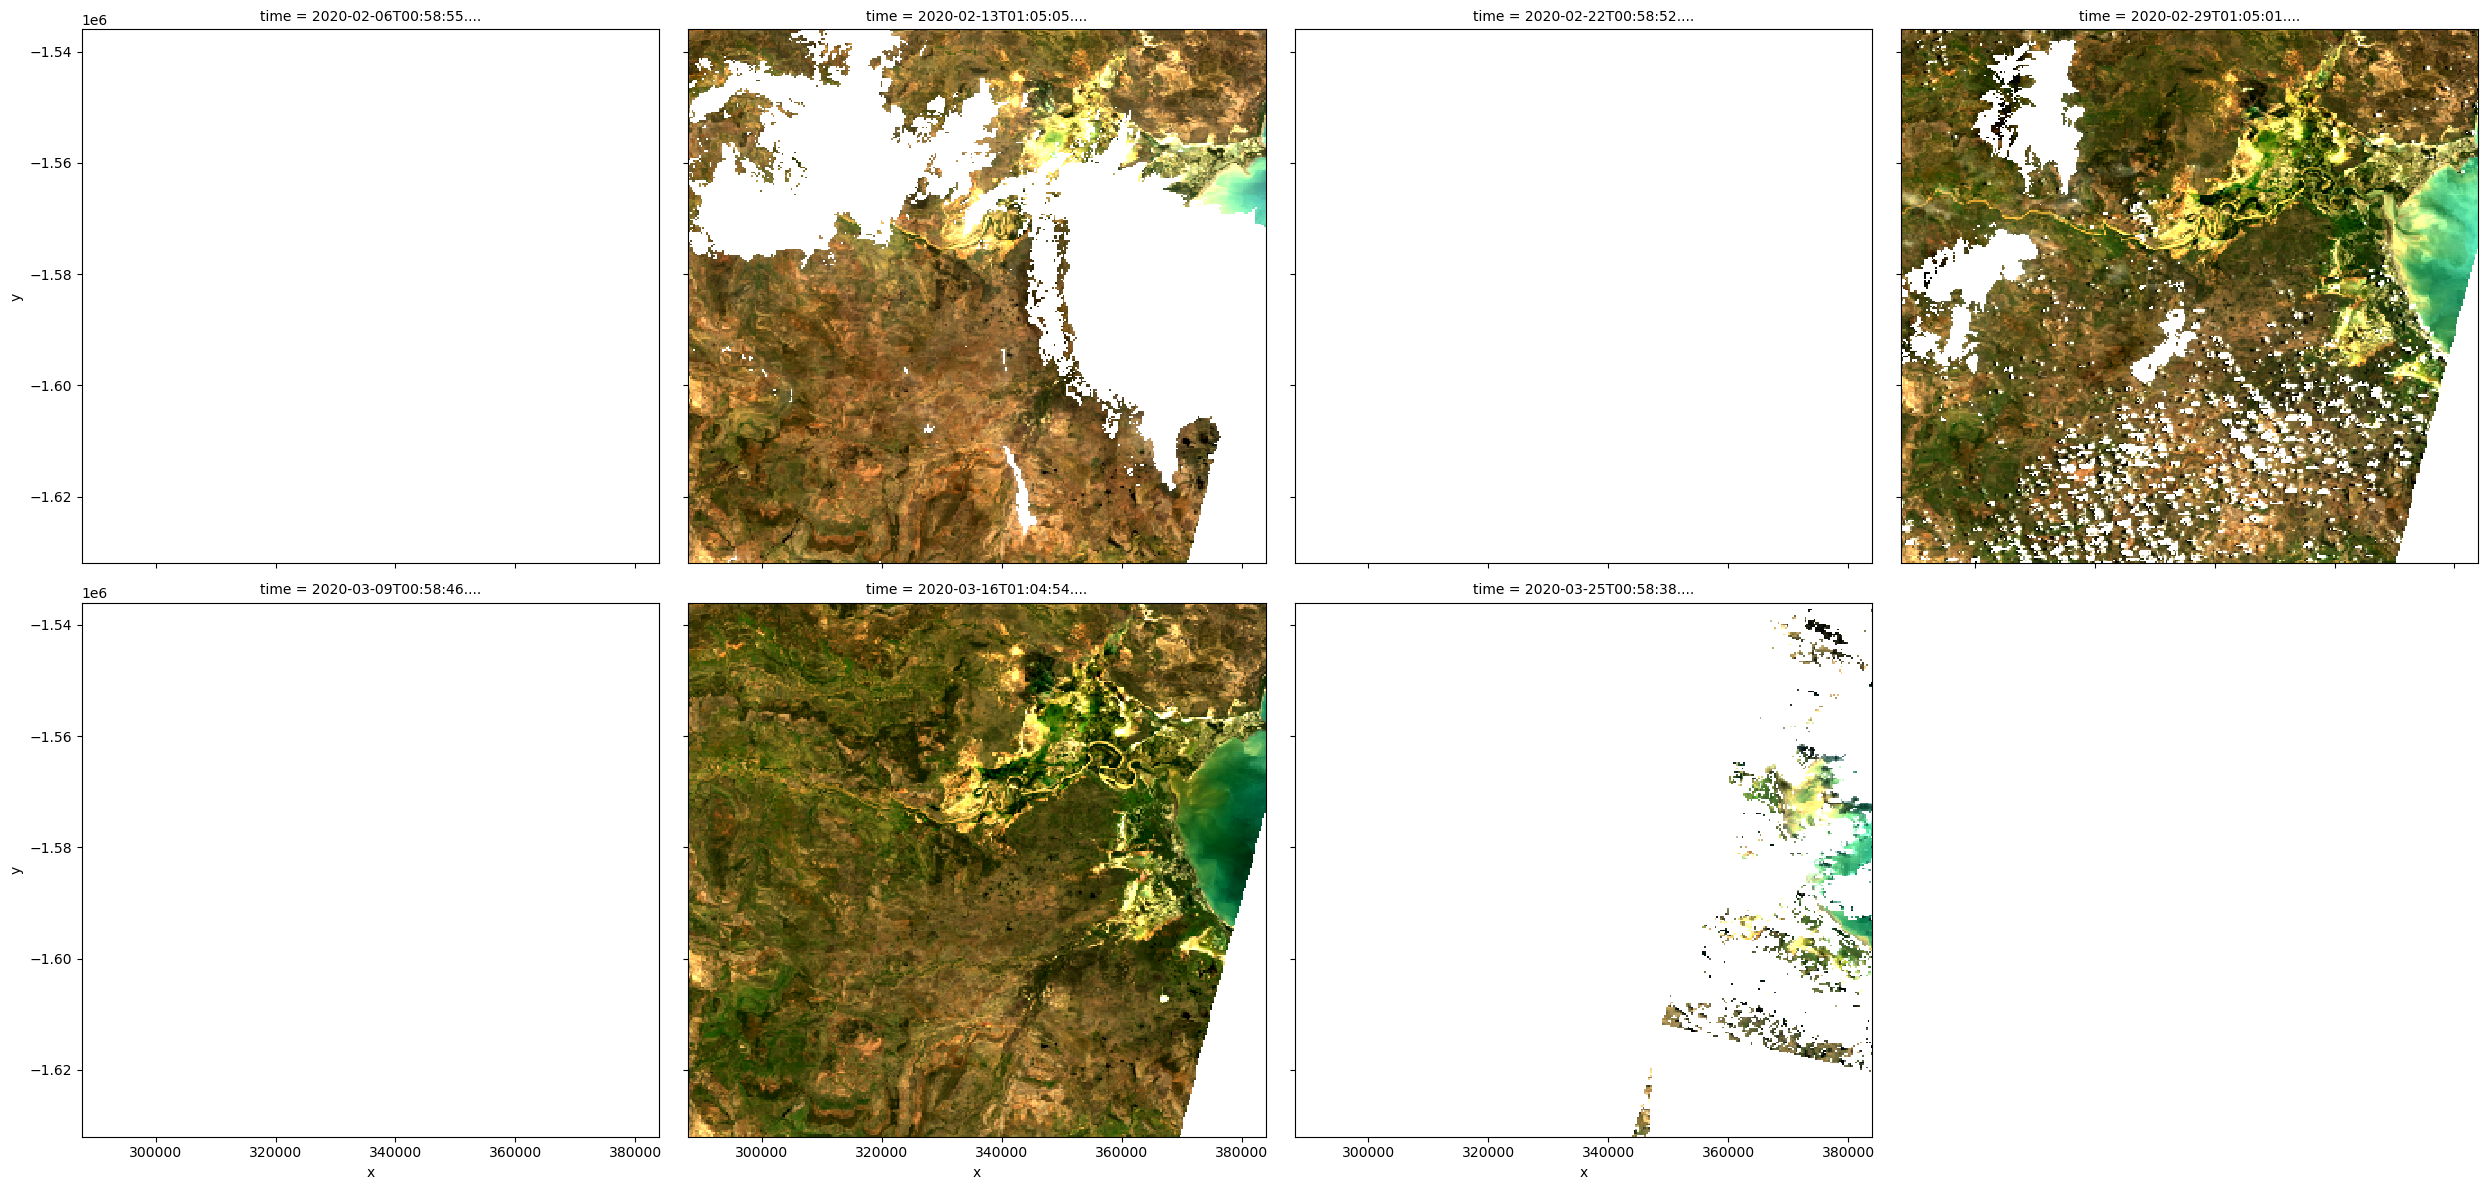

In [15]:
rgb(ds_l8, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col='time', robust=True, col_wrap=4)

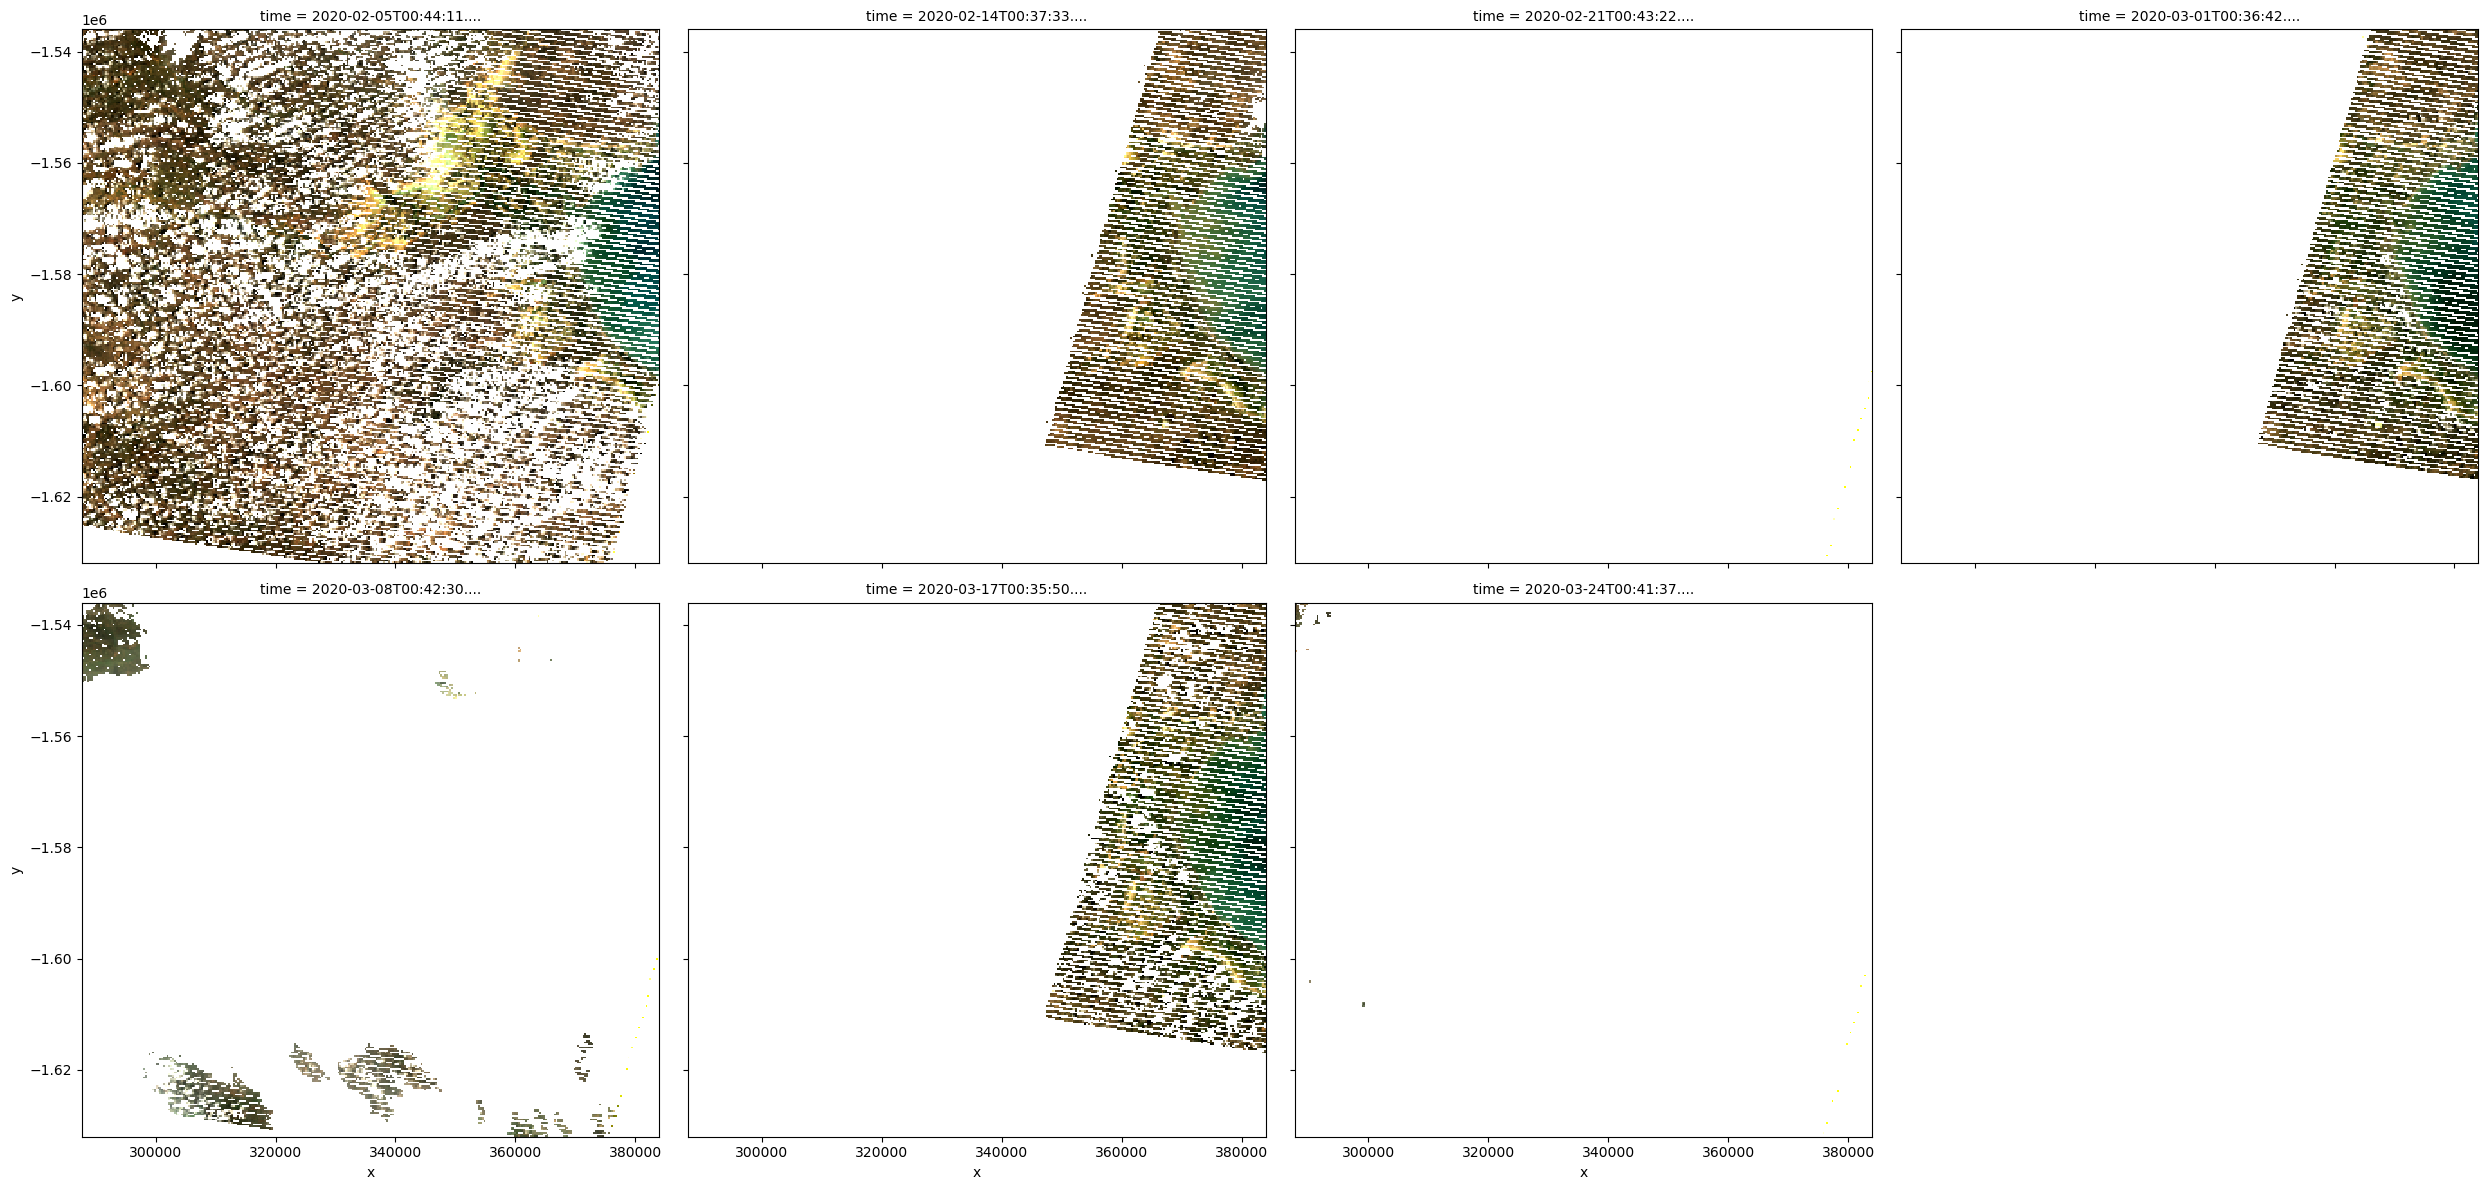

In [16]:
rgb(ds_l7, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col='time', robust=True, col_wrap=4)

In [17]:
# convert nodata from -999 to NaN before passing to the function
ds_l7 = masking.mask_invalid_data(ds_l7)
ds_l8 = masking.mask_invalid_data(ds_l8)
ds_l7

<xarray.Dataset> Size: 9MB
Dimensions:      (time: 7, y: 320, x: 321)
Coordinates:
  * time         (time) datetime64[ns] 56B 2020-02-05T00:44:11.880678 ... 202...
  * y            (y) float64 3kB -1.536e+06 -1.536e+06 ... -1.632e+06 -1.632e+06
  * x            (x) float64 3kB 2.878e+05 2.882e+05 ... 3.836e+05 3.838e+05
    spatial_ref  int32 4B 3577
Data variables:
    nbart_blue   (time, y, x) float32 3MB dask.array<chunksize=(7, 320, 321), meta=np.ndarray>
    nbart_green  (time, y, x) float32 3MB dask.array<chunksize=(7, 320, 321), meta=np.ndarray>
    nbart_red    (time, y, x) float32 3MB dask.array<chunksize=(7, 320, 321), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [18]:
filtered_ds_l8, filtered_ds_l7 = filter_dataset_within_timeframe(ds_l8, ds_l7, 3)

7
filtered_ds2 dims: FrozenMappingWarningOnValuesAccess({'time': 7, 'y': 320, 'x': 321})


In [19]:
filtered_ds_l7

<xarray.Dataset> Size: 9MB
Dimensions:      (time: 7, y: 320, x: 321)
Coordinates:
  * time         (time) datetime64[ns] 56B 2020-02-05T00:44:11.880678 ... 202...
  * y            (y) float64 3kB -1.536e+06 -1.536e+06 ... -1.632e+06 -1.632e+06
  * x            (x) float64 3kB 2.878e+05 2.882e+05 ... 3.836e+05 3.838e+05
    spatial_ref  int32 4B 3577
Data variables:
    nbart_blue   (time, y, x) float32 3MB dask.array<chunksize=(1, 320, 321), meta=np.ndarray>
    nbart_green  (time, y, x) float32 3MB dask.array<chunksize=(1, 320, 321), meta=np.ndarray>
    nbart_red    (time, y, x) float32 3MB dask.array<chunksize=(1, 320, 321), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

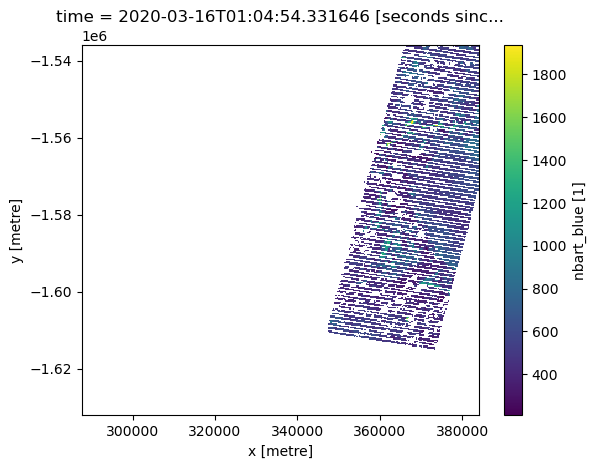

In [20]:
filtered_ds_l8.nbart_blue[5].plot()